In [23]:
import random
from os.path import join

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mnist_dataloader import *

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, Sequential

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [24]:
# Set file paths based on added MNIST Datasets

input_path = 'data/'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte')

In [25]:
# Helper function to show a list of images with their relating titles

def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

In [26]:
# Load MINST dataset

mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

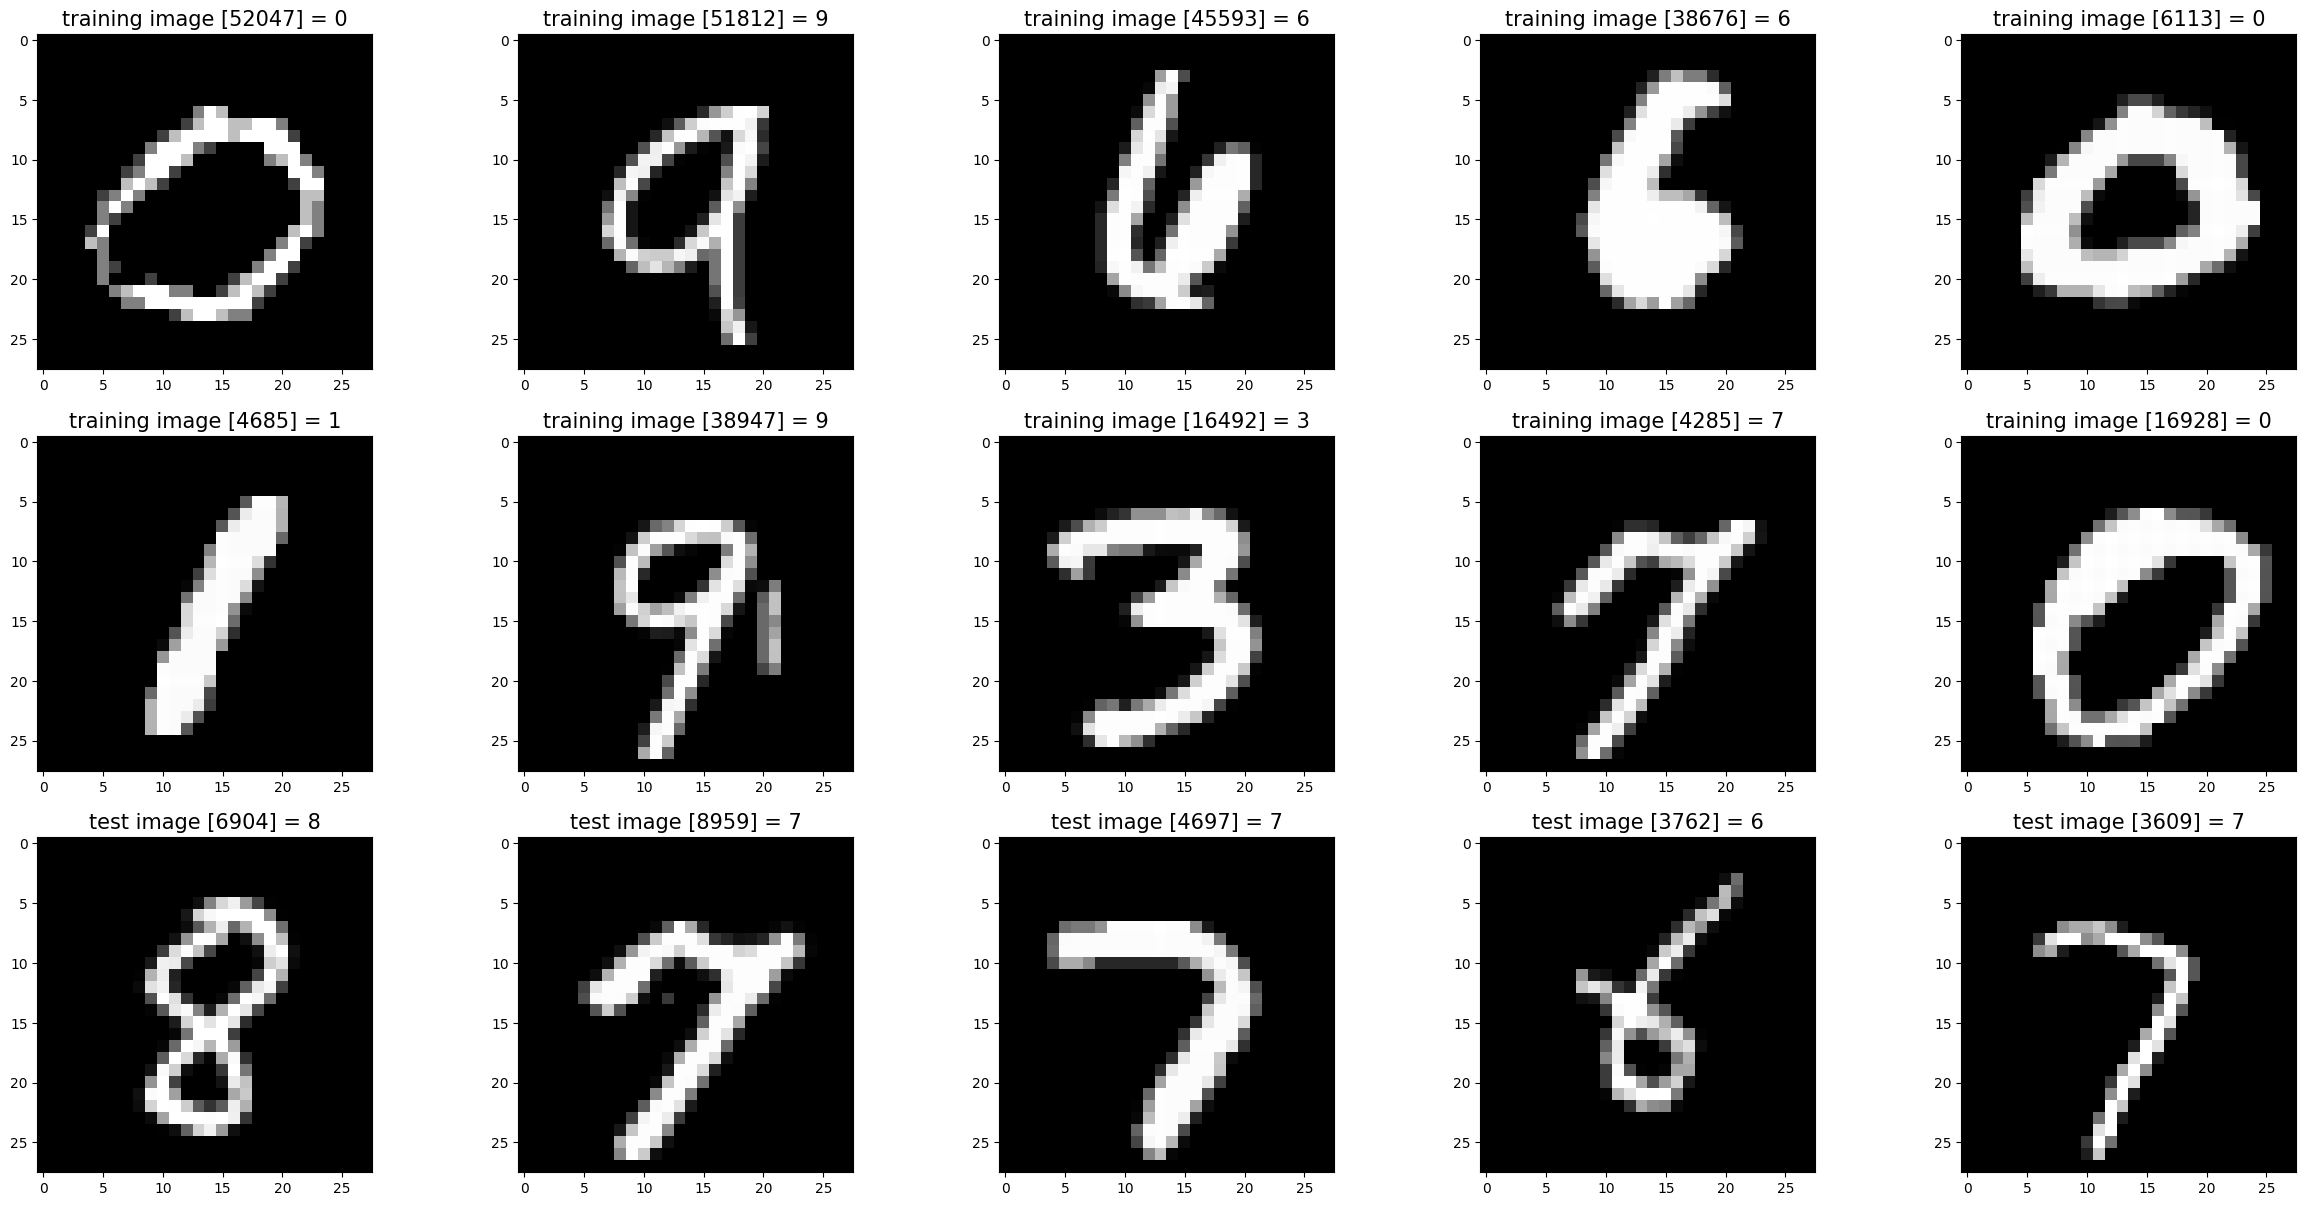

In [27]:
# Show some random training and test images 

images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

In [28]:
x_test, x_train = np.array(x_test), np.array(x_train)
y_test, y_train = np.array(y_test), np.array(y_train)

In [29]:
y_test[0], x_test[0].shape

(np.uint8(7), (28, 28))

In [30]:
pd.DataFrame(y_train).value_counts()

0
1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64

In [31]:
pd.DataFrame(y_test).value_counts()

0
1    1135
2    1032
7    1028
3    1010
9    1009
4     982
0     980
8     974
6     958
5     892
Name: count, dtype: int64

In [32]:
x_test.dtype, x_train.dtype

(dtype('uint8'), dtype('uint8'))

In [33]:
np.min(x_test), np.max(x_test)

(np.uint8(0), np.uint8(255))

In [34]:
np.min(x_train), np.max(x_train)

(np.uint8(0), np.uint8(255))

In [35]:
x_test.shape, y_test.shape

((10000, 28, 28), (10000,))

In [36]:
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [37]:
x_test, x_train = x_test / 255.0, x_train / 255.0

In [38]:
y_train = to_categorical(y_train)

y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [39]:
model = Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(1568, activation='relu'),
    layers.Dense(784, activation='relu'),
    layers.Dense(392, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [40]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [41]:
class PrintWeightsCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f'\nWeights after epoch {epoch + 1}:')
        for layer in self.model.layers:
            weights = layer.get_weights()
            if weights: 
                print(f'Layer {layer.name} weights: {weights[0].shape}')  
                print(weights[0])

In [42]:
history = model.fit(x_train, y_train, epochs=5, batch_size=256, callbacks=[PrintWeightsCallback()])

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8778 - loss: 0.4060
Weights after epoch 1:
Layer dense weights: (784, 1568)
[[ 0.02567929 -0.03728966  0.03684727 ...  0.01542579 -0.02661725
   0.02428605]
 [-0.03567576 -0.04947816  0.01678777 ...  0.02808823  0.00820061
  -0.02366069]
 [ 0.0409459  -0.01992119 -0.00159586 ... -0.04427765  0.00833596
  -0.04292796]
 ...
 [-0.0263193   0.0344744  -0.01988305 ...  0.04019242 -0.02900356
   0.02427479]
 [-0.03100149 -0.02004755  0.02073088 ... -0.00493575 -0.0153643
   0.0188082 ]
 [ 0.02937423 -0.04806853 -0.02815918 ...  0.00671939  0.02601416
  -0.02880736]]
Layer dense_1 weights: (1568, 784)
[[ 0.05174937 -0.05693131  0.00350473 ... -0.02297619  0.0078818
  -0.03189491]
 [ 0.02478707  0.01854243  0.06098208 ... -0.01536861  0.04259997
  -0.00742479]
 [-0.01409486  0.04358967 -0.04696078 ...  0.00256535  0.01803054
   0.00647845]
 ...
 [ 0.03528074 -0.02406159  0.03462642 ...  0.05023025 -0.02808894
   0.02055506]
 [ 

In [44]:
y_pred_prob = model.predict(x_test)

y_pred = np.argmax(y_pred_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [45]:
accuracy = accuracy_score(y_test, y_pred)

print(f'accuracy = {accuracy:.4f}')

accuracy = 0.9786


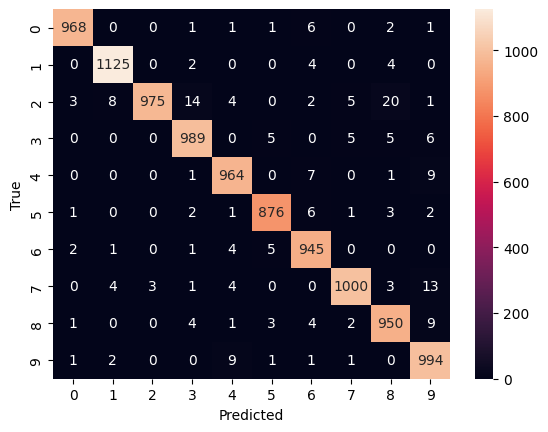

In [46]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


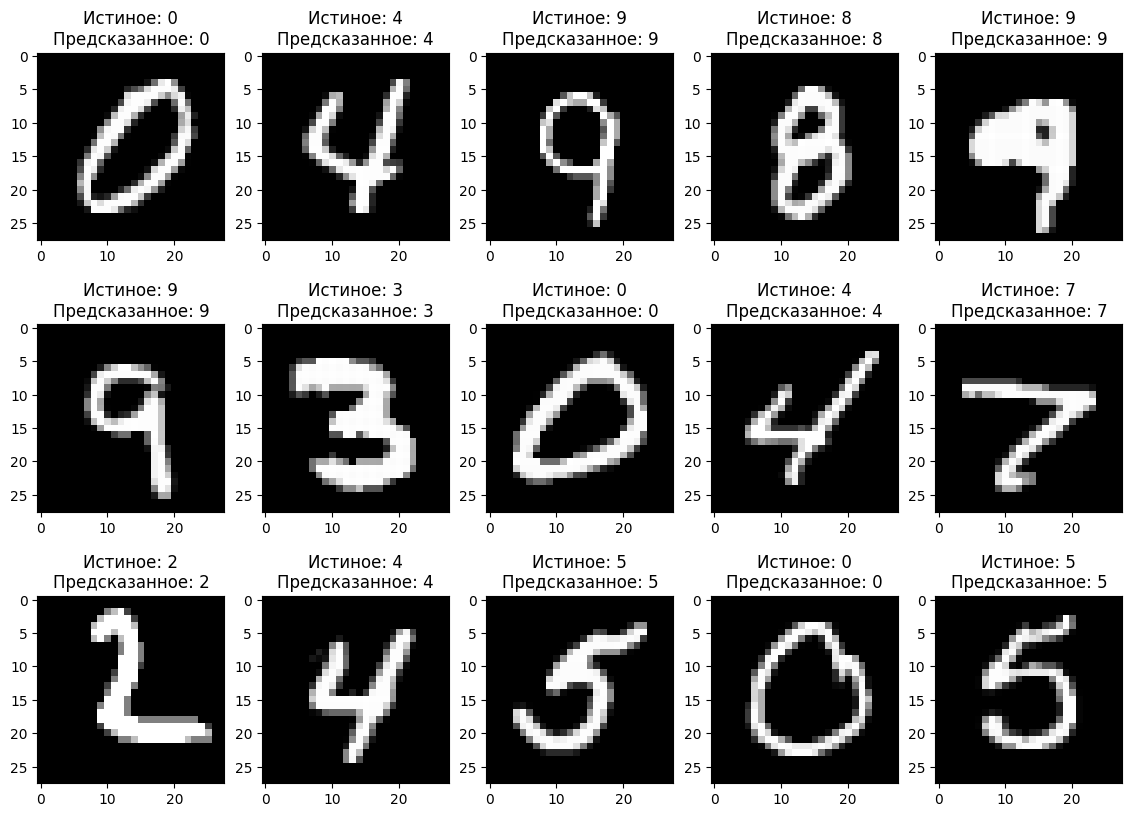

In [47]:
cols = 5
rows = 3

plt.figure(figsize=(14, 10))
   
for _ in range(cols * rows):   
    idx = random.randint(0, x_test.shape[0])

    image = x_test[idx]   
    true_label = y_test[idx]
    pred_label = np.argmax(model.predict(image.reshape(1, 28, 28)))

    plt.subplot(rows, cols, _ + 1)    

    plt.imshow(image, cmap=plt.cm.gray)

    plt.title(f'Истиное: {true_label}\nПредсказанное: {pred_label}'); 

plt.show()